# Light-map scintillator refractive-index comparison

This notebook compares the 0.4 mm-scattering, 1 mm-fibre maps made with `OpticalLiquidO` refractive indices 1.48 and 1.36. The untagged legacy/standard map uses **1.48** in `ND280UserDetectorConstruction`; it is not an n=1.49 map. The fibre model is unchanged at n=1.3 in both samples.

The comparisons use the same 970 valid source subvoxels and include total collection, summed efficiencies per fibre view, nearest-fibre response, view imbalance, distance dependence, and ten spatial difference/ratio slices.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from compare_lightmap_efficiencies import read_detailed_efficiencies

plt.rcParams.update({'figure.dpi': 115, 'axes.grid': True, 'grid.alpha': 0.22})
maps = Path('lightmaps')
output_dir = Path('lightmap_analysis/refractive_index_comparison_0p4mm')
output_dir.mkdir(parents=True, exist_ok=True)
settings = {
    'n = 1.48 (standard)': maps / 'homo_response_10bin_5m_0p4mm_100kPhotons.root',
    'n = 1.36': maps / 'homo_response_10bin_5m_0p4mm_fibre-1p0mm_scin-ri-1p36_100kPhotons.root',
}
for label, path in settings.items():
    if not path.exists():
        raise FileNotFoundError(f'{label}: {path}')
settings

{'n = 1.48 (standard)': PosixPath('lightmaps/homo_response_10bin_5m_0p4mm_100kPhotons.root'),
 'n = 1.36': PosixPath('lightmaps/homo_response_10bin_5m_0p4mm_fibre-1p0mm_scin-ri-1p36_100kPhotons.root')}

In [2]:
frames = {}
for label, path in settings.items():
    frame = pd.DataFrame(read_detailed_efficiencies(path))
    if len(frame) != 970:
        raise RuntimeError(f'{label}: expected 970 valid positions, found {len(frame)}')
    frames[label] = frame.sort_values(['x_mm', 'y_mm', 'z_mm']).reset_index(drop=True)

coordinates = ['x_mm', 'y_mm', 'z_mm']
reference_coordinates = frames[next(iter(frames))][coordinates].to_numpy()
for label, frame in frames.items():
    if not np.array_equal(frame[coordinates].to_numpy(), reference_coordinates):
        raise RuntimeError(f'{label}: source-position grid differs from the reference map')
print('Loaded and aligned:', {label: len(frame) for label, frame in frames.items()})

Loaded and aligned: {'n = 1.48 (standard)': 970, 'n = 1.36': 970}


Warning in <TClass::Init>: no dictionary for class ND::TND280Event is available
Warning in <TClass::Init>: no dictionary for class ND::TDataVector is available
Warning in <TClass::Init>: no dictionary for class ND::TData is available
Warning in <TClass::Init>: no dictionary for class ND::TDatum is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Context is available
Warning in <TClass::Init>: no dictionary for class ND::TSHAHashValue is available
Warning in <TClass::Init>: no dictionary for class ND::TAlignmentId is available
Warning in <TClass::Init>: no dictionary for class ND::TND280Event::Header is available


## Overall and per-view efficiency statistics

In [3]:
quantities = ['total', 'view_x', 'view_y', 'view_z', 'view_rms',
              'nearest_x', 'nearest_y', 'nearest_z', 'nearest_view_rms']
summary_rows = []
for label, frame in frames.items():
    for quantity in quantities:
        values = frame[quantity].to_numpy(float)
        summary_rows.append({
            'setting': label, 'quantity': quantity, 'mean': values.mean(),
            'minimum': values.min(), 'maximum': values.max(),
            'population_std': values.std(),
            'coefficient_of_variation': values.std() / values.mean() if values.mean() else np.nan,
        })
summary = pd.DataFrame(summary_rows)
summary.to_csv(output_dir / 'efficiency_statistics.csv', index=False)
display(summary.pivot(index='quantity', columns='setting', values=['mean', 'minimum', 'maximum', 'population_std']))

mean                       minimum                      \
setting           n = 1.36 n = 1.48 (standard)  n = 1.36 n = 1.48 (standard)   
quantity                                                                       
nearest_view_rms  0.094402            0.094404  0.000057            0.000048   
nearest_x         0.183389            0.183401  0.028850            0.028860   
nearest_y         0.183445            0.183457  0.028010            0.028010   
nearest_z         0.183418            0.183430  0.029520            0.029530   
total             0.870363            0.870520  0.865190            0.865290   
view_rms          0.080780            0.080781  0.000162            0.000173   
view_x            0.290109            0.290160  0.129810            0.129840   
view_y            0.290148            0.290200  0.128920            0.128970   
view_z            0.290107            0.290160  0.129150            0.129170   

                   maximum                     population_std  \
setting           n = 1.36 n = 1.48 (standard)       n = 1.36   
quantity                                                        
nearest_view_rms  0.212068            0.212063       0.056370   
nearest_x         0.504850            0.504850       0.111518   
nearest_y         0.506180            0.506190       0.111529   
nearest_z         0.504050            0.504060       0.111483   
total             0.874880            0.875030       0.001746   
view_rms          0.193712            0.193718       0.054655   
view_x            0.562540            0.562570       0.097536   
view_y            0.563380            0.563420       0.097496   
view_z            0.562140            0.562190       0.097569   

                                      
setting          n = 1.48 (standard)  
quantity                              
nearest_view_rms            0.056370  
nearest_x                   0.111519  
nearest_y                   0.111530  
nearest_z                   0.111484  
total                       0.001756  
view_rms                    0.054654  
view_x                      0.097536  
view_y                      0.097498  
view_z                      0.097570

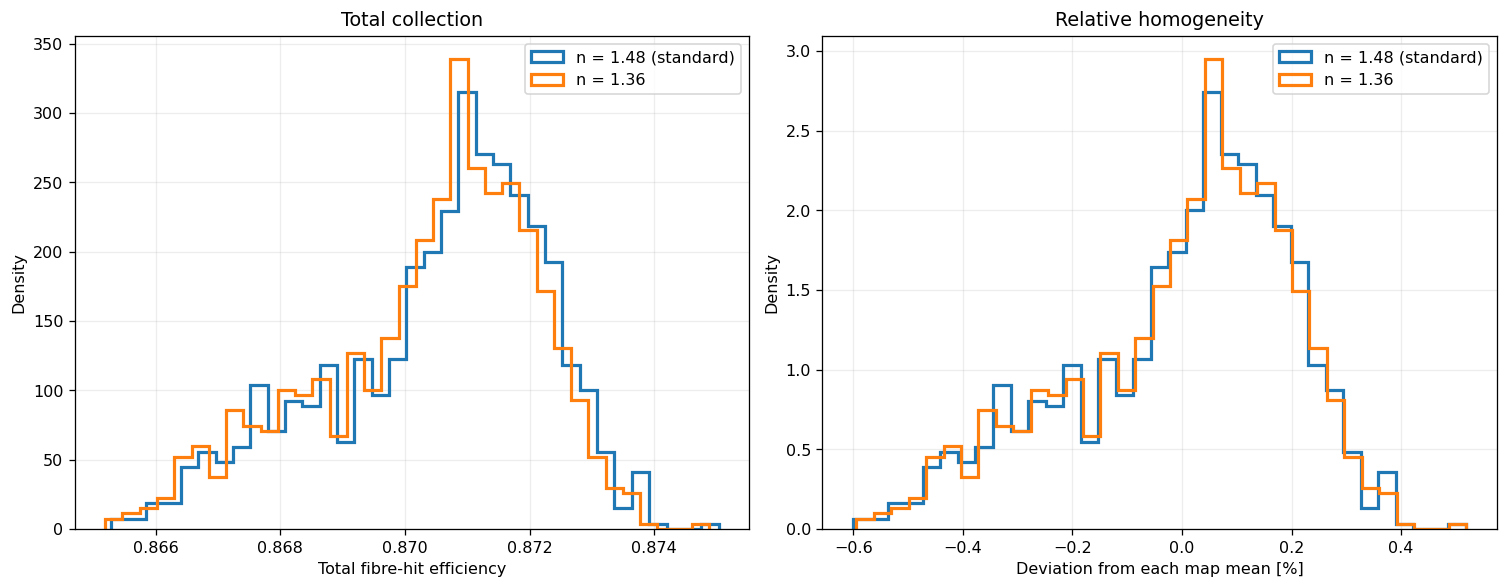

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for label, frame in frames.items():
    axes[0].hist(frame.total, bins=35, histtype='step', linewidth=2, density=True, label=label)
    relative = (frame.total - frame.total.mean()) / frame.total.mean() * 100
    axes[1].hist(relative, bins=35, histtype='step', linewidth=2, density=True, label=label)
axes[0].set(xlabel='Total fibre-hit efficiency', ylabel='Density', title='Total collection')
axes[1].set(xlabel='Deviation from each map mean [%]', ylabel='Density', title='Relative homogeneity')
for axis in axes: axis.legend()
fig.savefig(output_dir / 'total_efficiency_distributions.png', dpi=170)
plt.show()

## Position-by-position change from n=1.48 to n=1.36

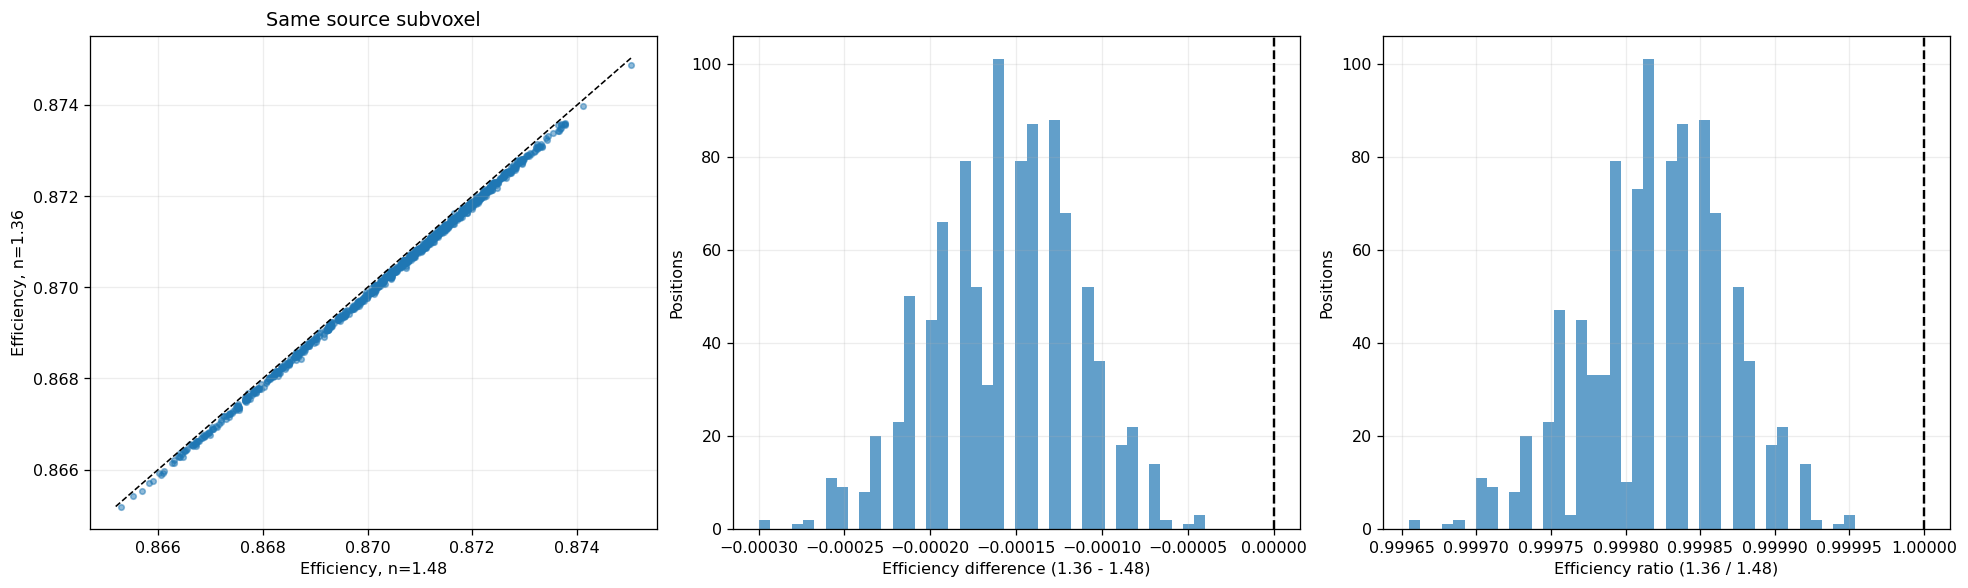

,total_difference,total_ratio
count,970.000000,970.000000
mean,-0.000157,0.999820
std,0.000042,0.000048
min,-0.000300,0.999655
25%,-0.000180,0.999793
50%,-0.000160,0.999817
75%,-0.000130,0.999851
max,-0.000040,0.999954


In [5]:
standard = frames['n = 1.48 (standard)']
changed = frames['n = 1.36']
comparison = standard[coordinates].copy()
for quantity in quantities:
    comparison[f'{quantity}_n1p48'] = standard[quantity]
    comparison[f'{quantity}_n1p36'] = changed[quantity]
    comparison[f'{quantity}_difference'] = changed[quantity] - standard[quantity]
    comparison[f'{quantity}_ratio'] = np.divide(changed[quantity], standard[quantity],
        out=np.full(len(changed), np.nan), where=standard[quantity].to_numpy() != 0)
comparison.to_csv(output_dir / 'position_by_position_comparison.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
axes[0].scatter(standard.total, changed.total, s=12, alpha=.5)
limits = [min(standard.total.min(), changed.total.min()), max(standard.total.max(), changed.total.max())]
axes[0].plot(limits, limits, 'k--', lw=1); axes[0].set(xlabel='Efficiency, n=1.48', ylabel='Efficiency, n=1.36', title='Same source subvoxel')
axes[1].hist(comparison.total_difference, bins=40, histtype='stepfilled', alpha=.7)
axes[1].axvline(0, color='black', ls='--'); axes[1].set(xlabel='Efficiency difference (1.36 - 1.48)', ylabel='Positions')
axes[2].hist(comparison.total_ratio, bins=40, histtype='stepfilled', alpha=.7)
axes[2].axvline(1, color='black', ls='--'); axes[2].set(xlabel='Efficiency ratio (1.36 / 1.48)', ylabel='Positions')
fig.savefig(output_dir / 'position_by_position_total_comparison.png', dpi=170)
plt.show()
comparison[['total_difference', 'total_ratio']].describe()

## Summed response in each fibre view and view-to-view imbalance

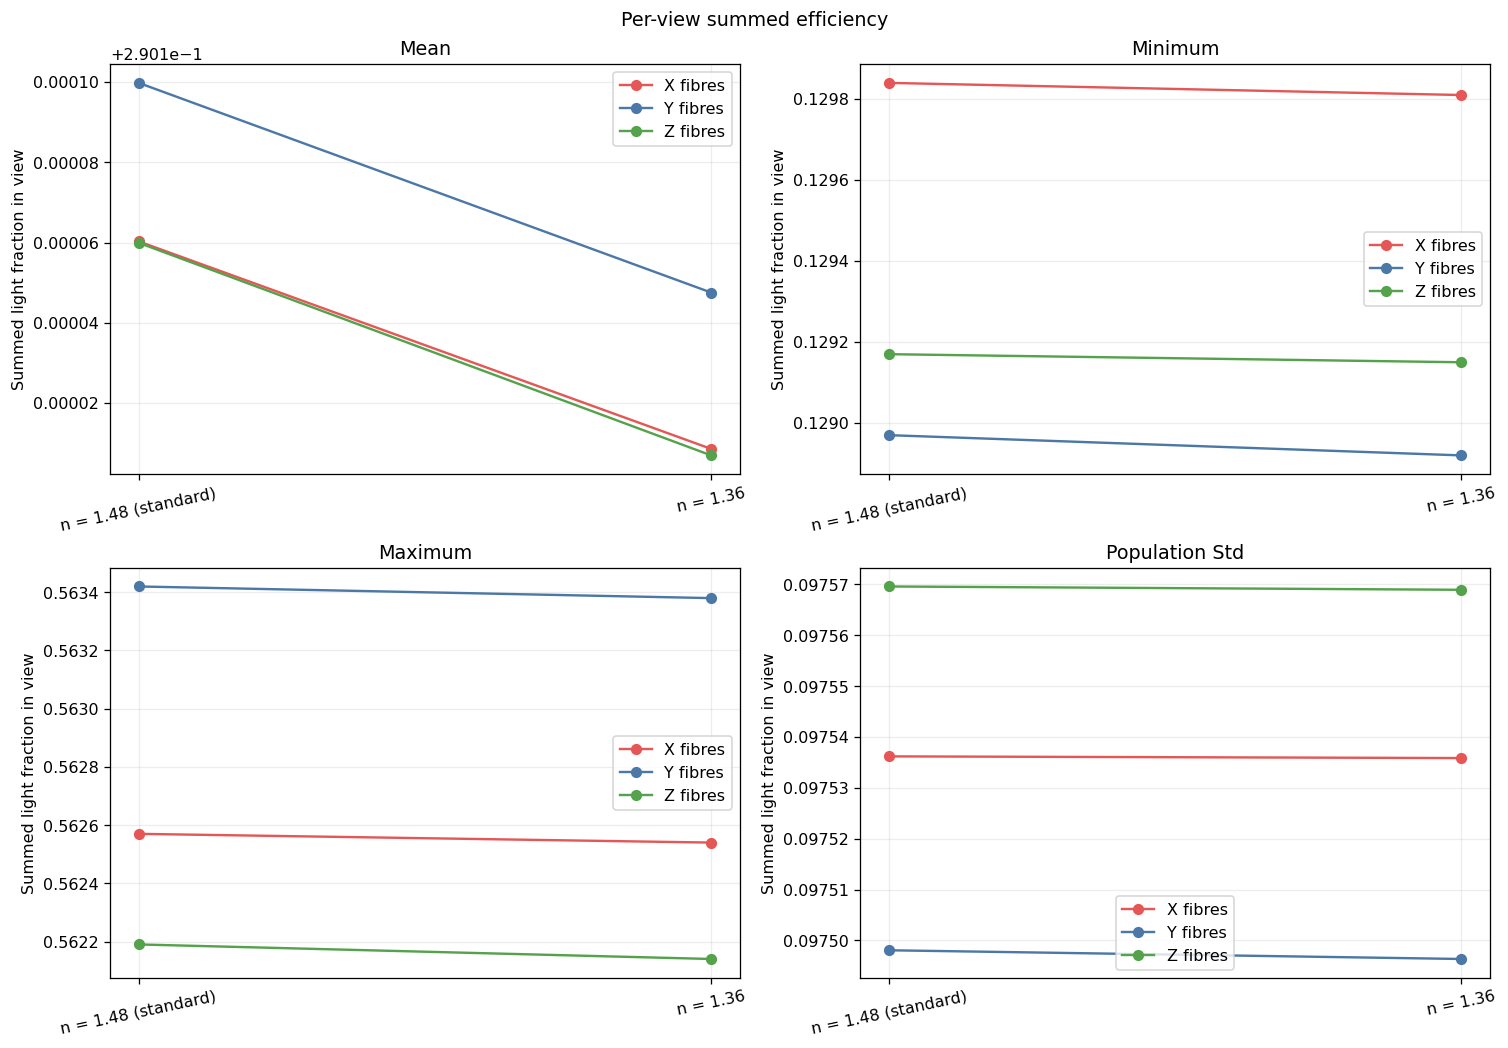

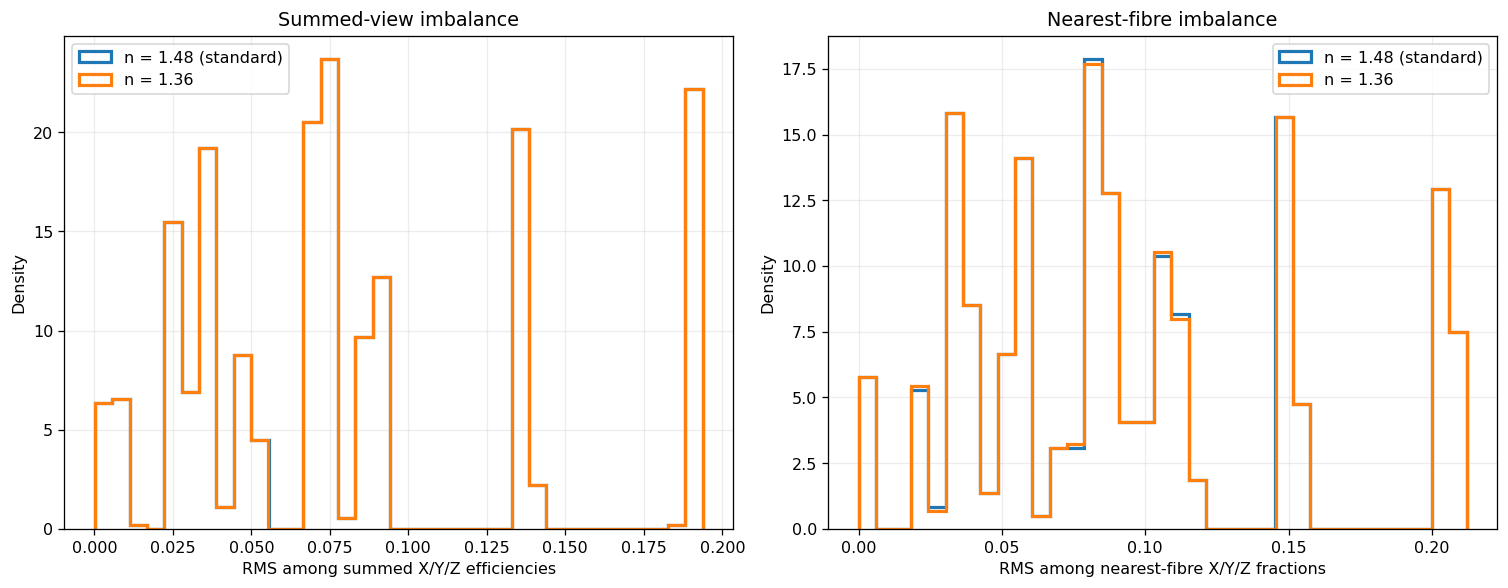

In [6]:
view_colours = {'x': '#e45756', 'y': '#4c78a8', 'z': '#54a24b'}
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for axis, statistic in zip(axes.flat, ('mean', 'minimum', 'maximum', 'population_std')):
    for view in 'xyz':
        selected = summary[summary.quantity == f'view_{view}'].set_index('setting')
        axis.plot(list(settings), selected.loc[list(settings), statistic], 'o-', color=view_colours[view], label=f'{view.upper()} fibres')
    axis.set(title=statistic.replace('_', ' ').title(), ylabel='Summed light fraction in view')
    axis.tick_params(axis='x', rotation=12); axis.legend()
fig.suptitle('Per-view summed efficiency')
fig.savefig(output_dir / 'per_view_efficiency_statistics.png', dpi=170)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for label, frame in frames.items():
    axes[0].hist(frame.view_rms, bins=35, histtype='step', linewidth=2, density=True, label=label)
    axes[1].hist(frame.nearest_view_rms, bins=35, histtype='step', linewidth=2, density=True, label=label)
axes[0].set(xlabel='RMS among summed X/Y/Z efficiencies', ylabel='Density', title='Summed-view imbalance')
axes[1].set(xlabel='RMS among nearest-fibre X/Y/Z fractions', ylabel='Density', title='Nearest-fibre imbalance')
for axis in axes: axis.legend()
fig.savefig(output_dir / 'view_imbalance_distributions.png', dpi=170)
plt.show()

## Fraction reaching the nearest fibre in each view

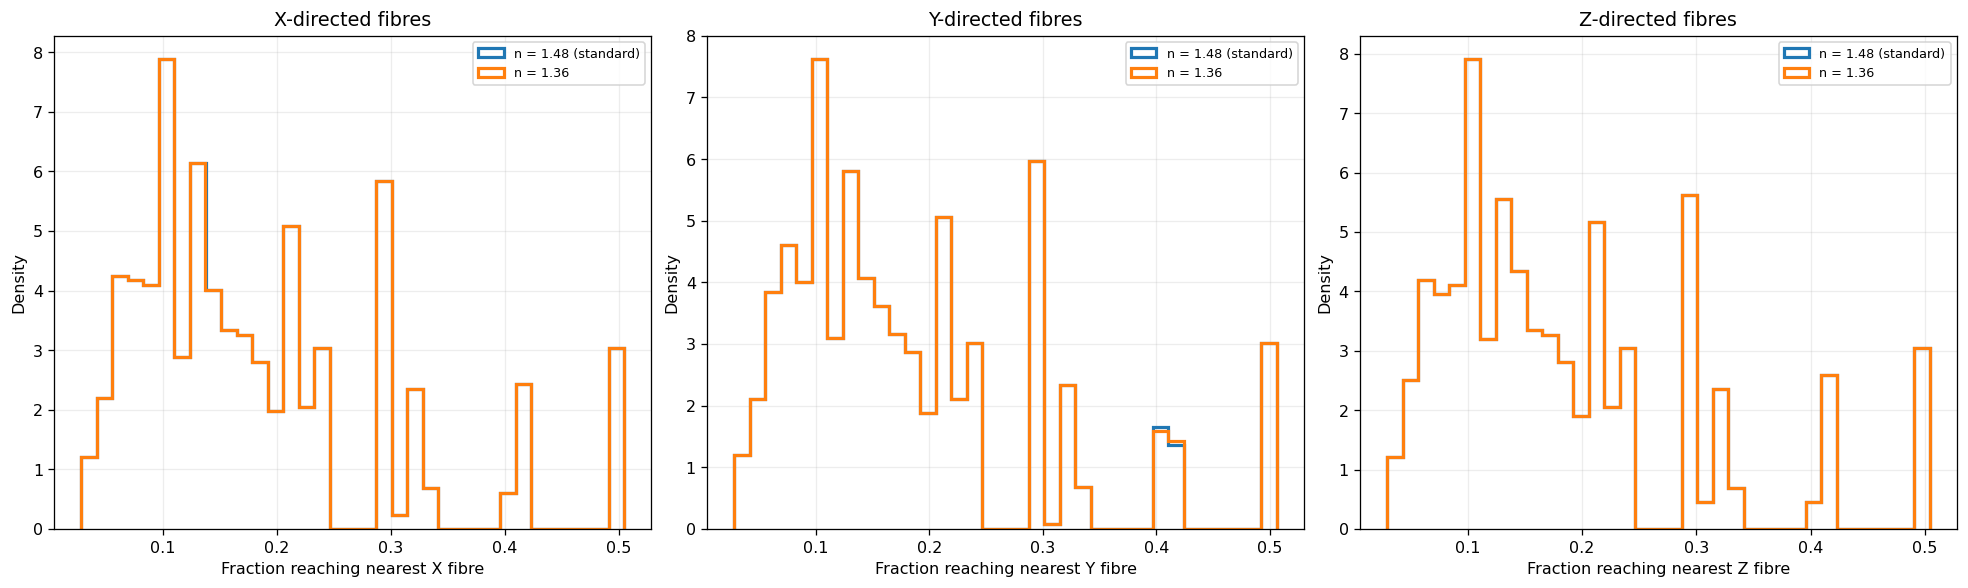

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), constrained_layout=True)
for axis, view in zip(axes, 'xyz'):
    for label, frame in frames.items():
        axis.hist(frame[f'nearest_{view}'], bins=35, histtype='step', linewidth=2, density=True, label=label)
    axis.set(xlabel=f'Fraction reaching nearest {view.upper()} fibre', ylabel='Density', title=f'{view.upper()}-directed fibres')
    axis.legend(fontsize=8)
fig.savefig(output_dir / 'nearest_fibre_distributions.png', dpi=170)
plt.show()

## Efficiency versus distance to the nearest fibre axis

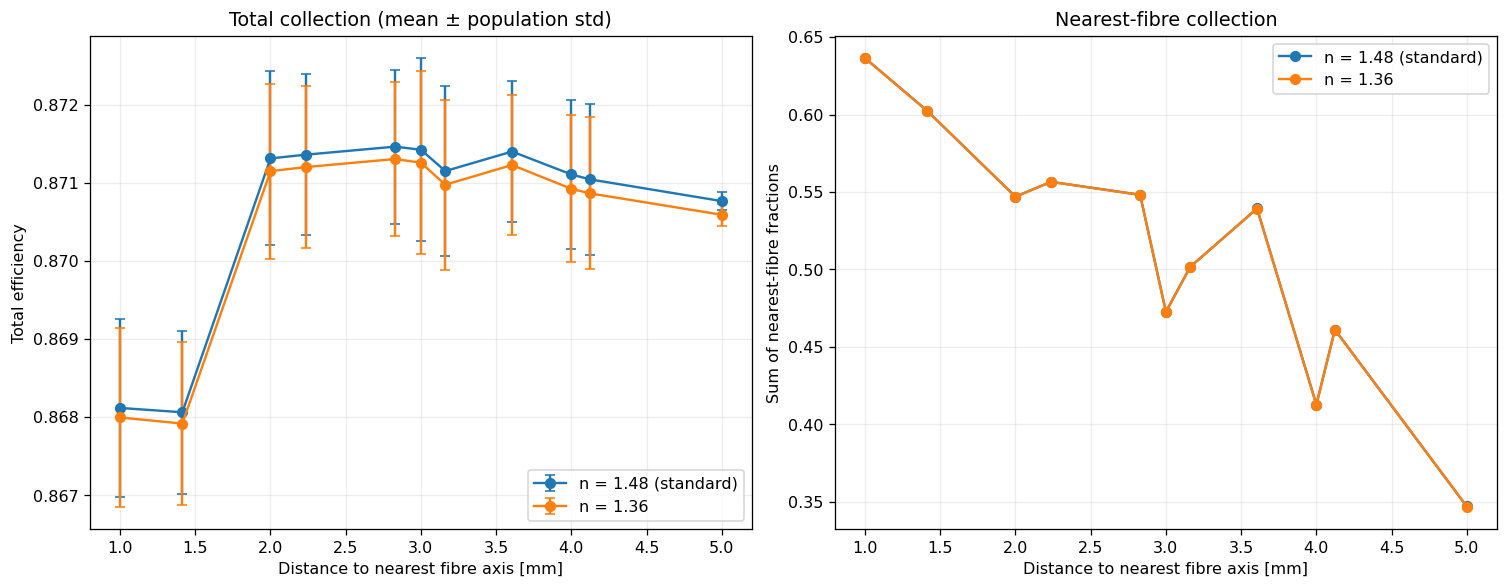

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
distance_table = []
for label, frame in frames.items():
    distance = frame[[f'nearest_distance_{v}_mm' for v in 'xyz']].min(axis=1).to_numpy()
    unique = np.unique(distance)
    means = np.array([frame.total.to_numpy()[distance == value].mean() for value in unique])
    stds = np.array([frame.total.to_numpy()[distance == value].std() for value in unique])
    axes[0].errorbar(unique, means, yerr=stds, marker='o', capsize=3, label=label)
    nearest_sum = frame[['nearest_x', 'nearest_y', 'nearest_z']].sum(axis=1).to_numpy()
    nearest_means = np.array([nearest_sum[distance == value].mean() for value in unique])
    axes[1].plot(unique, nearest_means, 'o-', label=label)
    distance_table.extend({'setting': label, 'distance_mm': d, 'total_mean': m, 'total_std': s, 'nearest_sum_mean': n}
                          for d, m, s, n in zip(unique, means, stds, nearest_means))
axes[0].set(xlabel='Distance to nearest fibre axis [mm]', ylabel='Total efficiency', title='Total collection (mean ± population std)')
axes[1].set(xlabel='Distance to nearest fibre axis [mm]', ylabel='Sum of nearest-fibre fractions', title='Nearest-fibre collection')
for axis in axes: axis.legend()
pd.DataFrame(distance_table).to_csv(output_dir / 'efficiency_vs_nearest_fibre_distance.csv', index=False)
fig.savefig(output_dir / 'efficiency_vs_nearest_fibre_distance.png', dpi=170)
plt.show()

## Ten spatial slices of the change

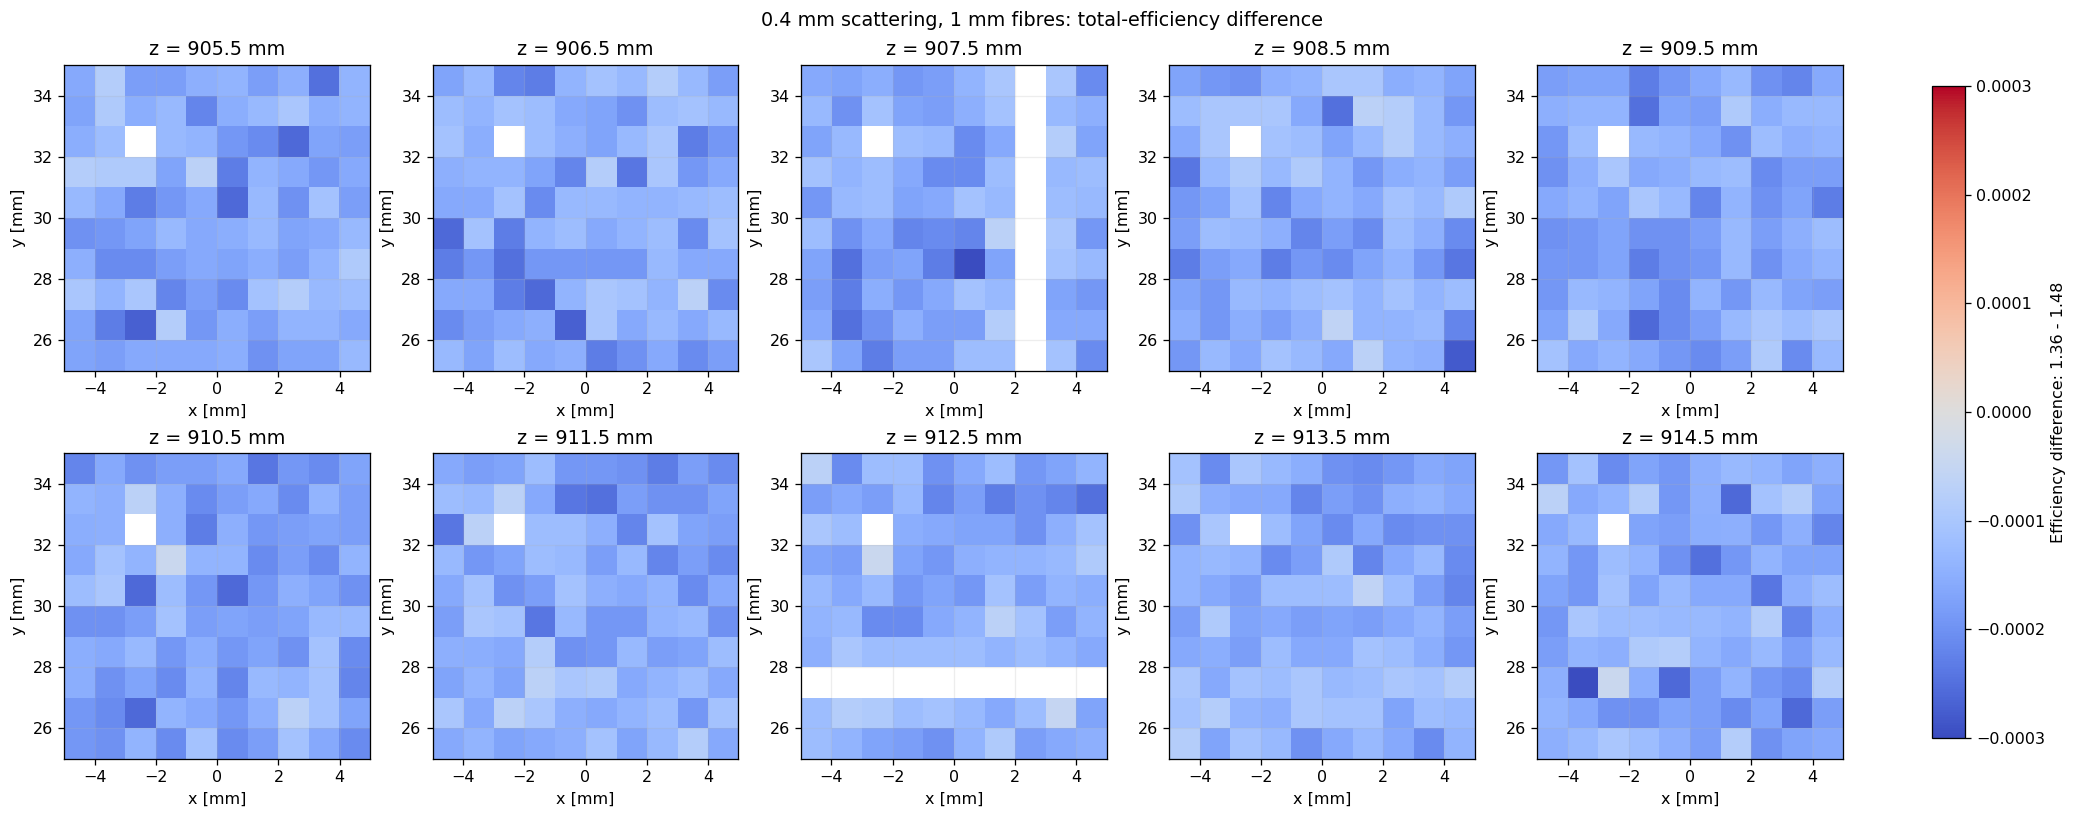

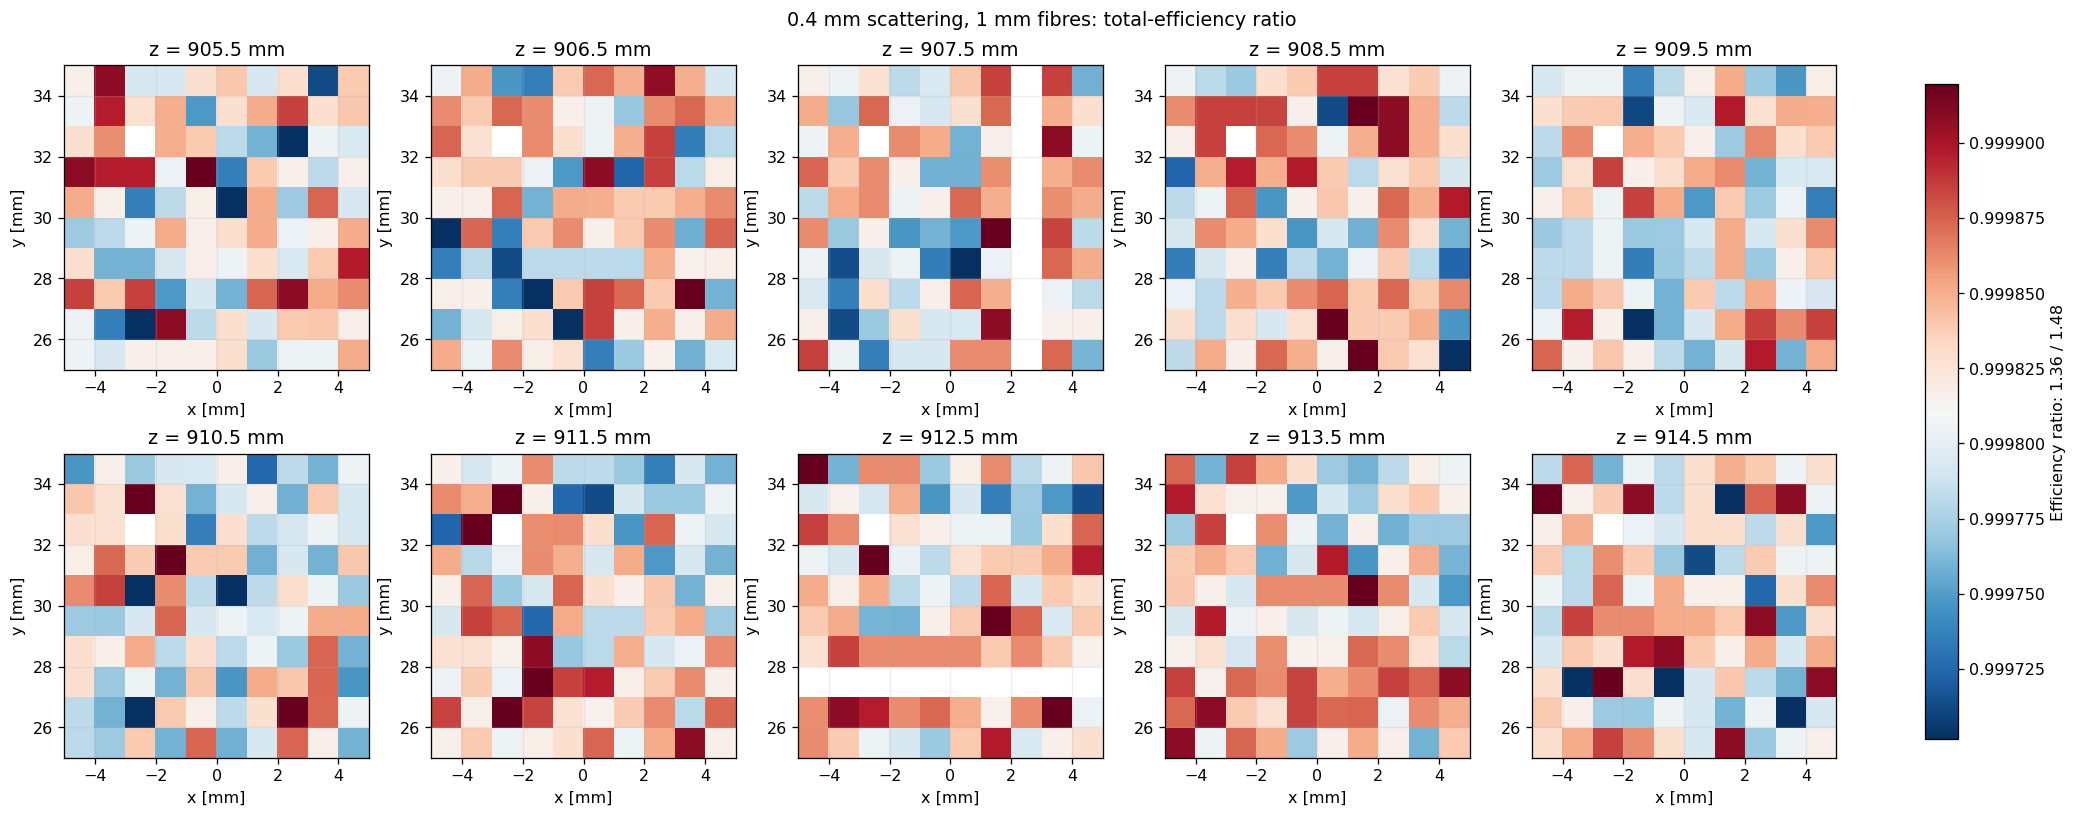

In [9]:
xs = np.sort(comparison.x_mm.unique()); ys = np.sort(comparison.y_mm.unique()); zs = np.sort(comparison.z_mm.unique())
lookup_difference = comparison.set_index(['x_mm', 'y_mm', 'z_mm']).total_difference
lookup_ratio = comparison.set_index(['x_mm', 'y_mm', 'z_mm']).total_ratio
difference_limit = np.nanmax(np.abs(comparison.total_difference))
for value_name, lookup, cmap, vmin, vmax, colour_label, filename in (
    ('difference', lookup_difference, 'coolwarm', -difference_limit, difference_limit, 'Efficiency difference: 1.36 - 1.48', 'total_efficiency_difference_10_slices.png'),
    ('ratio', lookup_ratio, 'RdBu_r', np.nanpercentile(comparison.total_ratio, 1), np.nanpercentile(comparison.total_ratio, 99), 'Efficiency ratio: 1.36 / 1.48', 'total_efficiency_ratio_10_slices.png')):
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
    image = None
    for axis, z in zip(axes.flat, zs):
        grid = np.full((len(ys), len(xs)), np.nan)
        for iy, y in enumerate(ys):
            for ix, x in enumerate(xs):
                grid[iy, ix] = lookup.get((x, y, z), np.nan)
        image = axis.imshow(grid, origin='lower', interpolation='nearest', cmap=cmap, vmin=vmin, vmax=vmax,
                            extent=(xs[0]-.5, xs[-1]+.5, ys[0]-.5, ys[-1]+.5))
        axis.set(title=f'z = {z:g} mm', xlabel='x [mm]', ylabel='y [mm]')
    fig.colorbar(image, ax=axes, label=colour_label, shrink=.9)
    fig.suptitle(f'0.4 mm scattering, 1 mm fibres: total-efficiency {value_name}')
    fig.savefig(output_dir / filename, dpi=170)
    plt.show()

## Interpretation reminder

This is a controlled optical-interface diagnostic, not a physically final material model: both maps retain the current n=1.3 fibre. Lowering the scintillator from 1.48 to 1.36 raises the scintillator-to-fibre critical angle and reduces the range of incident angles subject to total internal reflection, but it does not remove it because 1.36 remains above 1.3.